In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [2]:
titanic=sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [9]:
# Handle Missing Values
imp_median = SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_most_frequent=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_most_frequent.fit_transform(titanic[["embarked"]])

In [15]:
# Encoding
le = LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [28]:
X=titanic[features]
y=titanic[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [29]:
# Decision Tree Model - No Pruning
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)
print(f"accuracy score: {accuracy_score(y_test,y_pred)}")

accuracy score: 0.7686567164179104


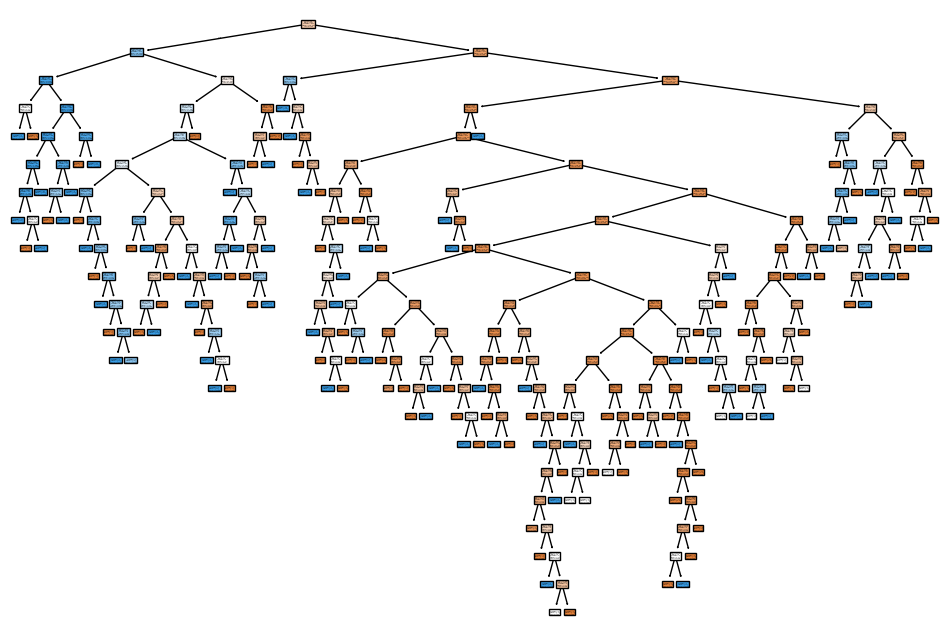

In [31]:
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
)
plt.show()

# Decision Tree with Pre Pruning

In [32]:
max_depth=[2,3,4,5,6,7,8,9]
for i in max_depth:
    model = DecisionTreeClassifier(max_depth=i)
    model.fit(X_train, y_train)
    print(model.score(X_test,y_test))

0.7723880597014925
0.8059701492537313
0.8246268656716418
0.7947761194029851
0.7873134328358209
0.7761194029850746
0.8059701492537313
0.7723880597014925


In [33]:
min_samples_splits = [5,10,15,20,25]
for i in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4,min_samples_split=i)
    model.fit(X_train, y_train)
    print(model.score(X_test, y_test))

0.8246268656716418
0.8246268656716418
0.8171641791044776
0.8171641791044776
0.8208955223880597


# Decision Tree with Post Pruning

In [36]:
full_tree =DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [37]:
trees=[]
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha)
    model.fit(X_train,y_train)
    accuracy=model.score(X_test,y_test)

    trees.append((accuracy,alpha))

In [40]:
best_alpha=0
best_accuracy=0

for accuracy,alpha in trees:
    if accuracy>best_accuracy:
        best_accuracy=accuracy
        best_alpha=alpha

print(best_alpha)
print(best_accuracy)


0.0017121455323702516
0.8208955223880597


In [41]:
full_tree = DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)
full_tree.fit(X_train, y_train)
print(full_tree.score(X_test,y_test))

0.8208955223880597


IndexError: list index out of range

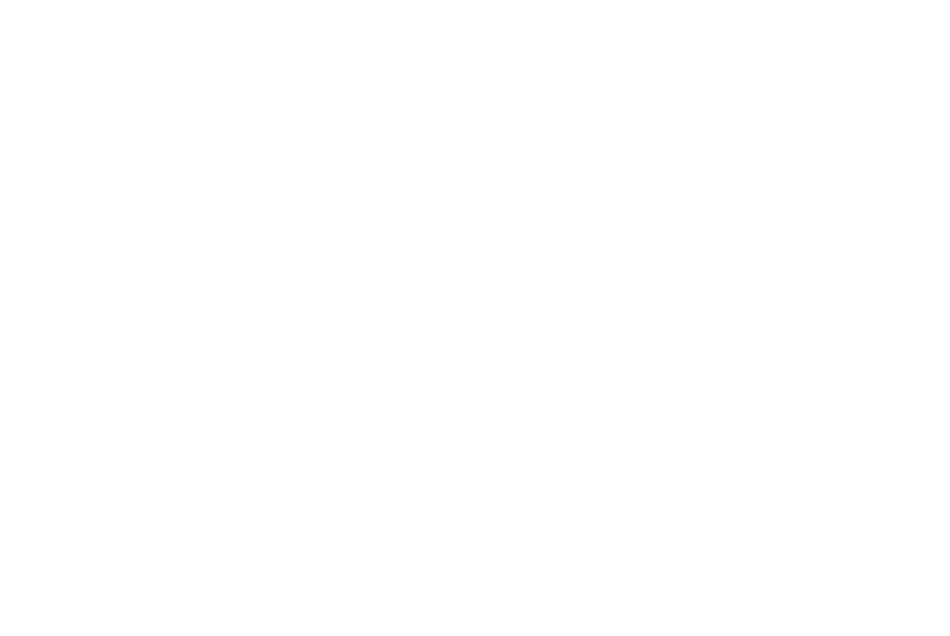

In [44]:
plt.figure(figsize=(12,8))
plot_tree(
    full_tree, feature_names=X.columns, class_names=["Died,Survived"], filled=True
)
plt.show()